              AAPL      MSFT  GBPUSD=X
20250210  0.001187  0.006010 -0.003700
20250211  0.021597 -0.001894 -0.002500
20250212  0.018105 -0.005850  0.007332
20250213  0.019482  0.003660 -0.000075
20250214  0.012630 -0.005153  0.009017
...            ...       ...       ...
20260202  0.039779 -0.016213 -0.009263
20260203 -0.001965 -0.029142 -0.000438
20260204  0.025680  0.007221  0.001779
20260205 -0.002100 -0.050812 -0.003869
20260206  0.007978  0.018798 -0.001840

[241 rows x 3 columns]


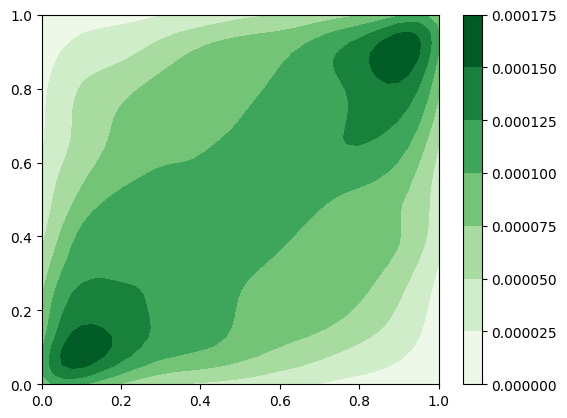

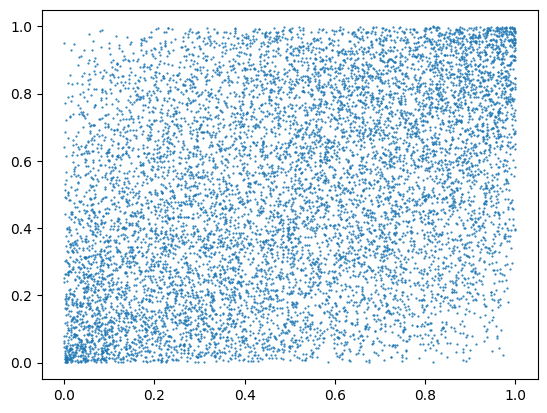

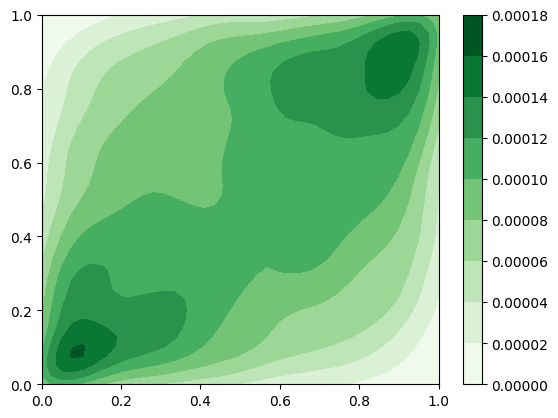

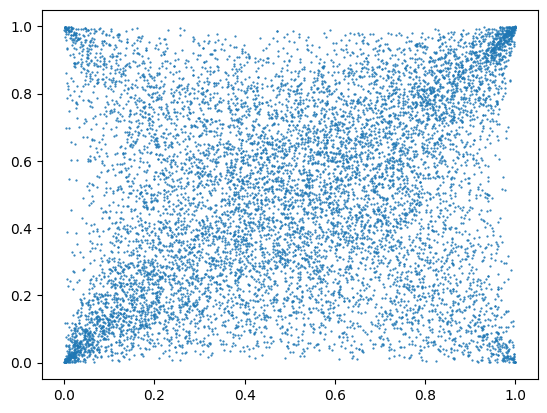

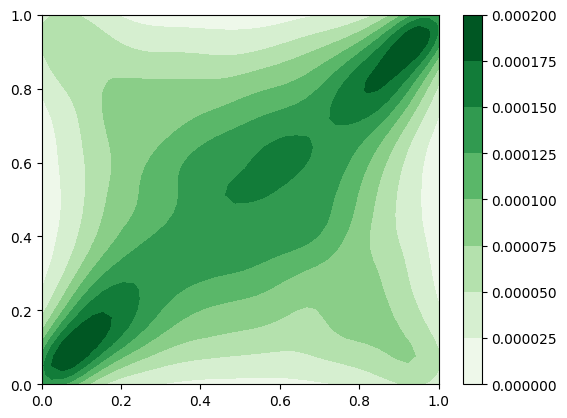

In [8]:
import market as mkt
import jointsim as js


data = mkt.get_market(ticker_list=['AAPL', 'MSFT', 'GBPUSD=X'], period='1y', interval='1d')
print(data)

rf_dir = [1.0, 1.0, -1.0]
copula = js.GaussCopulaCorr(data, rf_dir)
copula.get_sims(10000)
copula.plot_contour(0, 1)

rf_dir = [1.0, 1.0, -1.0]
copula = js.GaussCopulaNum(data, rf_dir)
copula.get_sims(10000)
copula.plot_sims(0, 1)
copula.plot_contour(0, 1)

rf_dir = [1.0, 1.0, -1.0]
copula = js.CauchyCopulaNum(data, rf_dir)
copula.get_sims(10000)
copula.plot_sims(0, 1)
copula.plot_contour(0, 1)




In [2]:
import market as mkt
import jointsim as js
import var as v
import pandas as pd
import numpy as np

returns, spot = mkt.get_market(ticker_list=['AAPL', 'MSFT', 'GBPUSD=X'], period='1y', interval='1d')

rf_dir = [1.0, 1.0, -1.0]
copula = js.GaussCopulaNum(returns, rf_dir, seed=0)
port_var = v.MCVar(returns, spot, copula, np.array(rf_dir), method='midpoint')
port_var.calculate_pnls(10000)
print(f'Value-at-risk: {port_var.get_quantile(0.99)}, while portfolio value: {port_var.get_port_value()}')
print(port_var.name)


Value-at-risk: 28.193840022715758, while portfolio value: 677.8989285230637
MC VaR - Empirical marginals (midpoint) - Gaussian copula (numerical simulation)
